In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.tsa.api import VAR
from statsmodels.stats.stattools import durbin_watson
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [60]:
df = pd.read_csv('/Users/elyas/vscode/market_analysis_03_office/data/preprocessed_not_standardized.csv')

In [61]:
# Step 0. Variable Selection
# -----------------------------
# Based on domain expertise, list the key variables you want to include.
selected_vars = [
    'appreciation_return', 
    'availability_rate',
    'available_df_direct', 
    'avg_sale_price', 
    'cap_rate', 
    'market_cap_rate',
    'starts_sf', 
    'starts_sf_12_mo', 
    'demand_sf', 
    'demolished_sf',
    'gross_delivered_sf', 
    'inventory_sf', 
    'leasing_sf_total',
    'asking_rent_growth', 
    'asking_rent_growth_12_mo', 
    'net_absorp_sf',
    'net_absorp_sf_12_mo', 
    'net_delivered_sf', 
    'net_delivered_sf_12_mo',
    'occupancy_rate', 
    'sales_volume',
    'sold_building_sf', 
    'vacancy_rate',
    'under_construction_sf', 
    'total_sales_transactions', 
    'fed_funds_rate',
    'bond_yield_10yr', 
    'availability'
]

In [62]:
df.head()

,period,appreciation_return,availability_rate,available_df_direct,avg_sale_price,cap_rate,market_cap_rate,starts_sf,starts_sf_12_mo,demand_sf,...,six_yr_inf_exp,seven_yr_inf_exp,eight_yr_inf_exp,nine_yr_inf_exp,ten_yr_inf_exp,ten_yr_risk_premium,fed_funds_rate,cmbs_to_gdp,bond_yield_10yr_y,availability
0,2000-01-01,1.996212,NaN,NaN,5662759.0,9.864546,9.707598,3513818.0,13834133.0,233634640.0,...,3.334707,3.332517,3.328459,3.323236,3.317285,1.321698,5.676667,10.858744,6.480000,NaN
1,2000-04-01,0.029603,NaN,NaN,4170181.0,10.243572,9.737211,3087883.0,12950512.0,238588112.0,...,3.296978,3.286445,3.276708,3.267590,3.258982,1.240777,6.273333,10.895663,6.176667,NaN
2,2000-07-01,-0.951823,NaN,NaN,3275183.0,10.488000,9.913068,4253537.0,13824219.0,236425552.0,...,3.074912,3.066052,3.058823,3.052792,3.047656,1.187069,6.520000,11.034501,5.893333,NaN
3,2000-10-01,-2.447272,NaN,NaN,4558434.0,10.368750,9.950081,2549278.0,13404516.0,238998704.0,...,2.959286,2.948705,2.940997,2.935303,2.931051,1.176115,6.473333,11.178302,5.566667,NaN
4,2001-01-01,-3.037886,NaN,NaN,1512973.0,10.986154,10.011605,1146188.0,11036886.0,239546624.0,...,2.538486,2.541324,2.545846,2.551512,2.557932,1.138131,5.593333,10.963645,5.050000,NaN


In [63]:
# Step 1. Data Preparation
# -----------------------------
# (a) Set the time index and filter the DataFrame to include only the selected variables.
# 'period' is already set as the index and assumed to be in datetime format.
# = df.set_index('period')
# Using all variables; no need to filter columns.

# (b) Define your target variable.
target_variable = 'market_cap_rate'

In [28]:
# Step 2. Data Transformation & Stationarity Checks
# -----------------------------
# We will perform the following transformations:
#   A. Variance Stabilization via log-transformation (when appropriate)
#   B. First Differencing to help achieve stationarity
#   C. Seasonal Differencing (if needed)
#   D. Final selection of stationary series

# A. Variance Stabilization
cv_threshold = 0.5  # threshold for applying log transform
# We'll keep track of how we transform the target variable.
target_transformation = None

# Create a new DataFrame to hold the transformed columns.
df_transformed = pd.DataFrame(index=df.index)

# Loop through each numeric column
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

for col in numeric_cols:
    series = df[col].dropna()
    if series.min() > 0:
        cv = series.std() / series.mean()
        if cv > cv_threshold:
            # Apply log transformation if coefficient of variation is high
            df_transformed[f'log_{col}'] = np.log(series)
            if col == target_variable:
                target_transformation = f'log_{col}'
        else:
            # Otherwise, keep the original series (rename for clarity)
            df_transformed[f'orig_{col}'] = series
            if col == target_variable:
                target_transformation = f'orig_{col}'
    else:
        # If the series contains non-positive values, keep it unchanged
        df_transformed[f'orig_{col}'] = series
        if col == target_variable:
            target_transformation = f'orig_{col}'

# B. First Differencing to remove trends (if series is non-stationary)
df_diff = df_transformed.copy()  # start with the transformed data

# For each transformed column, check stationarity using the ADF test and difference if necessary.
transformed_cols = [col for col in df_transformed.columns if col.startswith(('log_', 'orig_'))]
for col in transformed_cols:
    series = df_transformed[col].dropna()
    adf_pvalue = adfuller(series)[1]
    if adf_pvalue > 0.05:
        # The series appears non-stationary, so take first difference.
        base_name = col.split('_', 1)[1]
        df_diff[f'd1_{base_name}'] = df_transformed[col].diff()
        # For the target variable, update transformation name if differencing is applied.
        if base_name == target_variable:
            target_transformation = f'd1_{base_name}'
    else:
        # Series is stationary; copy it as is.
        df_diff[col] = df_transformed[col]

# Remove NA values generated by differencing.
df_diff = df_diff.dropna()

# C. Seasonal Differencing (if necessary)
seasonal_period = 8  # adjust this to your seasonality (e.g., quarterly data might use 4; here 8 is just an example)
df_seasonal = df_diff.copy()
differenced_cols = [col for col in df_diff.columns if col.startswith('d1_')]

for col in differenced_cols:
    series = df_diff[col].dropna()
    try:
        adf_pvalue = adfuller(series)[1]
        if adf_pvalue > 0.05:
            # Apply seasonal differencing if the series still appears non-stationary.
            df_seasonal[f'sd{seasonal_period}_{col}'] = series.diff(seasonal_period)
    except Exception as e:
        print(f"Skipping seasonal differencing for {col} due to error: {e}")

# Remove any additional NAs.
df_seasonal = df_seasonal.dropna()

In [65]:
# D. Final Stationary Selection
# We select only the series that are now stationary based on the ADF test.
final_columns = []
for col in df_seasonal.columns:
    # We expect our stationary series to have names starting with either 'd1_' or 'sd{seasonal_period}_'
    if col.startswith(f'sd{seasonal_period}_') or col.startswith('d1_'):
        try:
            p_value = adfuller(df_seasonal[col].dropna())[1]
            if p_value < 0.05:
                final_columns.append(col)
        except Exception as e:
            print(f"ADF test could not be performed for {col}: {e}")

# Ensure that our target variable (after transformation) is included.
if target_transformation not in final_columns:
    final_columns.append(target_transformation)

# Final stationary DataFrame ready for further analysis.
stationary_df = df_seasonal[final_columns].dropna()

In [ ]:
# Step 3. (Optional) Dimensionality Reduction via Dynamic Factoring PCA
# -----------------------------
# Note: In practice, here you would perform a dynamic factoring PCA to reduce collinearity.
# You might use libraries like sklearn or factor_analyzer, and then interpret the factors.
# For example:
#   - Standardize the stationary_df (except the target, if desired)
#   - Run PCA to extract key factors
#   - Replace the original variables with these factor scores in your VAR model
# This section is left as a placeholder for your custom implementation.

In [ ]:
# Step 4 Granger Causality Testing

candidate_vars = [col for col in stationary_df.columns if col != target_transformation]
significant_vars = []
results_dict = {}  # to store p-values for each variable

maxlag = 8       # maximum lag to test
p_threshold = 0.05  # significance level

for var in candidate_vars:
    print(f"\nTesting Granger causality for variable: {var}")
    try:
        # Test if candidate variable Granger-causes the target variable.
        test_result = grangercausalitytests(
            stationary_df[[target_transformation, var]], 
            maxlag=maxlag, 
            verbose=False
        )
        p_values = []
        # Extract and print the p-value from the F-test for each lag.
        for i in range(maxlag):
            p_val = test_result[i+1][0]['ssr_ftest'][1]
            p_values.append(p_val)
            print(f"  Lag {i+1}: p-value = {p_val:.4f}")
        
        results_dict[var] = p_values
        # Determine if the variable is significant based on the minimum p-value.
        if min(p_values) < p_threshold:
            print(f"  => {var} is SIGNIFICANT (min p-value = {min(p_values):.4f})")
            significant_vars.append(var)
        else:
            print(f"  => {var} is NOT significant (min p-value = {min(p_values):.4f})")
    except Exception as e:
        print(f"  Error testing Granger causality for {var}: {e}")

# Summarize the p-values for each candidate variable.
print("\nSummary of Granger causality test results:")
for var, p_vals in results_dict.items():
    print(f"  {var}: {p_vals}")


Testing Granger causality for variable: d1_appreciation_return
  Lag 1: p-value = 0.0000
  Lag 2: p-value = 0.0000
  Lag 3: p-value = 0.0000
  Lag 4: p-value = 0.0000
  Lag 5: p-value = 0.0000
  Lag 6: p-value = 0.0000
  Lag 7: p-value = 0.0000
  Lag 8: p-value = 0.0000
  => d1_appreciation_return is SIGNIFICANT (min p-value = 0.0000)

Testing Granger causality for variable: d1_available_df_direct
  Lag 1: p-value = 0.1244
  Lag 2: p-value = 0.3063
  Lag 3: p-value = 0.0289
  Lag 4: p-value = 0.0384
  Lag 5: p-value = 0.0623
  Lag 6: p-value = 0.0655
  Lag 7: p-value = 0.0971
  Lag 8: p-value = 0.2353
  => d1_available_df_direct is SIGNIFICANT (min p-value = 0.0289)

Testing Granger causality for variable: d1_cap_rate
  Lag 1: p-value = 0.9934
  Lag 2: p-value = 0.9175
  Lag 3: p-value = 0.9602
  Lag 4: p-value = 0.9645
  Lag 5: p-value = 0.9941
  Lag 6: p-value = 0.9581
  Lag 7: p-value = 0.9372
  Lag 8: p-value = 0.9403
  => d1_cap_rate is NOT significant (min p-value = 0.9175)

Tes

/Users/elyas/Applications/anaconda3/envs/gatech_02/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/elyas/Applications/anaconda3/envs/gatech_02/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/elyas/Applications/anaconda3/envs/gatech_02/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/elyas/Applications/anaconda3/envs/gatech_02/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/elyas/Applications/anaconda3/envs/gatech_02/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since fu

  Lag 1: p-value = 0.2842
  Lag 2: p-value = 0.6523
  Lag 3: p-value = 0.1520
  Lag 4: p-value = 0.0291
  Lag 5: p-value = 0.0200
  Lag 6: p-value = 0.0967
  Lag 7: p-value = 0.1086
  Lag 8: p-value = 0.2094
  => d1_inventory_sf is SIGNIFICANT (min p-value = 0.0200)

Testing Granger causality for variable: d1_asking_rent_growth
  Lag 1: p-value = 0.0912
  Lag 2: p-value = 0.2251
  Lag 3: p-value = 0.3330
  Lag 4: p-value = 0.3378
  Lag 5: p-value = 0.2307
  Lag 6: p-value = 0.1623
  Lag 7: p-value = 0.2962
  Lag 8: p-value = 0.2131
  => d1_asking_rent_growth is NOT significant (min p-value = 0.0912)

Testing Granger causality for variable: d1_asking_rent_growth_12_mo
  Lag 1: p-value = 0.0003
  Lag 2: p-value = 0.1338
  Lag 3: p-value = 0.2384
  Lag 4: p-value = 0.3933
  Lag 5: p-value = 0.4747
  Lag 6: p-value = 0.4092
  Lag 7: p-value = 0.5775
  Lag 8: p-value = 0.1943
  => d1_asking_rent_growth_12_mo is SIGNIFICANT (min p-value = 0.0003)

Testing Granger causality for variable: d1_n

/Users/elyas/Applications/anaconda3/envs/gatech_02/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/elyas/Applications/anaconda3/envs/gatech_02/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/elyas/Applications/anaconda3/envs/gatech_02/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/elyas/Applications/anaconda3/envs/gatech_02/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/elyas/Applications/anaconda3/envs/gatech_02/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since fu

  Lag 1: p-value = 0.7480
  Lag 2: p-value = 0.8803
  Lag 3: p-value = 0.6572
  Lag 4: p-value = 0.5834
  Lag 5: p-value = 0.5228
  Lag 6: p-value = 0.0833
  Lag 7: p-value = 0.0310
  Lag 8: p-value = 0.0008
  => d1_bond_yield_10yr_x is SIGNIFICANT (min p-value = 0.0008)

Testing Granger causality for variable: d1_two_yr_inf_exp
  Lag 1: p-value = 0.3467
  Lag 2: p-value = 0.4024
  Lag 3: p-value = 0.1177
  Lag 4: p-value = 0.1042
  Lag 5: p-value = 0.1256
  Lag 6: p-value = 0.1062
  Lag 7: p-value = 0.0422
  Lag 8: p-value = 0.0001
  => d1_two_yr_inf_exp is SIGNIFICANT (min p-value = 0.0001)

Testing Granger causality for variable: d1_three_yr_inf_exp
  Lag 1: p-value = 0.4323
  Lag 2: p-value = 0.4192
  Lag 3: p-value = 0.1766
  Lag 4: p-value = 0.1438
  Lag 5: p-value = 0.1722
  Lag 6: p-value = 0.1224
  Lag 7: p-value = 0.0409
  Lag 8: p-value = 0.0001
  => d1_three_yr_inf_exp is SIGNIFICANT (min p-value = 0.0001)

Testing Granger causality for variable: d1_four_yr_inf_exp
  Lag 1:

/Users/elyas/Applications/anaconda3/envs/gatech_02/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/elyas/Applications/anaconda3/envs/gatech_02/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/elyas/Applications/anaconda3/envs/gatech_02/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/elyas/Applications/anaconda3/envs/gatech_02/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/elyas/Applications/anaconda3/envs/gatech_02/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since fu

  Lag 1: p-value = 0.7347
  Lag 2: p-value = 0.2289
  Lag 3: p-value = 0.4026
  Lag 4: p-value = 0.3478
  Lag 5: p-value = 0.3035
  Lag 6: p-value = 0.1636
  Lag 7: p-value = 0.0997
  Lag 8: p-value = 0.0008
  => d1_fed_funds_rate is SIGNIFICANT (min p-value = 0.0008)

Testing Granger causality for variable: d1_cmbs_to_gdp
  Lag 1: p-value = 0.0006
  Lag 2: p-value = 0.3437
  Lag 3: p-value = 0.5312
  Lag 4: p-value = 0.4844
  Lag 5: p-value = 0.4586
  Lag 6: p-value = 0.2580
  Lag 7: p-value = 0.1530
  Lag 8: p-value = 0.0025
  => d1_cmbs_to_gdp is SIGNIFICANT (min p-value = 0.0006)

Testing Granger causality for variable: d1_bond_yield_10yr_y
  Lag 1: p-value = 0.7480
  Lag 2: p-value = 0.8803
  Lag 3: p-value = 0.6572
  Lag 4: p-value = 0.5834
  Lag 5: p-value = 0.5228
  Lag 6: p-value = 0.0833
  Lag 7: p-value = 0.0310
  Lag 8: p-value = 0.0008
  => d1_bond_yield_10yr_y is SIGNIFICANT (min p-value = 0.0008)

Testing Granger causality for variable: sd8_d1_under_construction_sf
  Lag

/Users/elyas/Applications/anaconda3/envs/gatech_02/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/elyas/Applications/anaconda3/envs/gatech_02/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/elyas/Applications/anaconda3/envs/gatech_02/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


In [70]:
# Build the filtered DataFrame including the target and only the significant predictors.
filtered_df = stationary_df[[target_transformation] + significant_vars]

print(f"\nFiltered dataset shape: {filtered_df.shape}")
print(f"Variables included: {filtered_df.columns.tolist()}")


Filtered dataset shape: (67, 21)
Variables included: ['orig_market_cap_rate', 'd1_appreciation_return', 'd1_available_df_direct', 'd1_demand_sf', 'd1_inventory_sf', 'd1_asking_rent_growth_12_mo', 'd1_net_delivered_sf', 'd1_net_delivered_sf_12_mo', 'd1_bond_yield_10yr_x', 'd1_two_yr_inf_exp', 'd1_three_yr_inf_exp', 'd1_four_yr_inf_exp', 'd1_five_yr_inf_exp', 'd1_six_yr_inf_exp', 'd1_seven_yr_inf_exp', 'd1_eight_yr_inf_exp', 'd1_nine_yr_inf_exp', 'd1_ten_yr_inf_exp', 'd1_fed_funds_rate', 'd1_cmbs_to_gdp', 'd1_bond_yield_10yr_y']


In [71]:
#drop the variable d1_bond_yield_10yr_y
filtered_df = filtered_df.drop(columns=['d1_bond_yield_10yr_y'])

In [73]:
#remove all variables ending with yr_inf_exp except for d1_three_yr_inf_exp
filtered_df = filtered_df.drop(columns=[col for col in filtered_df.columns if 'yr_inf_exp' in col and col != 'd1_three_yr_inf_exp'])

In [75]:
### Check for multicollinearity

from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

def calculate_vif(df):
    """Calculate VIF for each variable in the dataset."""
    vif_data = pd.DataFrame()
    vif_data["Variable"] = df.columns
    vif_data["VIF"] = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]
    return vif_data

# Calculate VIF for the filtered dataset (excluding the target variable)
X = filtered_df.drop(columns=[target_transformation])  # predictors only
vif_df = calculate_vif(X)
print(vif_df)


                       Variable       VIF
0        d1_appreciation_return  1.522266
1        d1_available_df_direct  2.243714
2                  d1_demand_sf  2.024178
3               d1_inventory_sf  2.032192
4   d1_asking_rent_growth_12_mo  1.610586
5           d1_net_delivered_sf  1.645796
6     d1_net_delivered_sf_12_mo  1.605448
7          d1_bond_yield_10yr_x  2.533384
8           d1_three_yr_inf_exp  2.873186
9             d1_fed_funds_rate  2.108299
10               d1_cmbs_to_gdp  2.111284


In [77]:
print(filtered_df.columns) 

Index(['orig_market_cap_rate', 'd1_appreciation_return',
       'd1_available_df_direct', 'd1_demand_sf', 'd1_inventory_sf',
       'd1_asking_rent_growth_12_mo', 'd1_net_delivered_sf',
       'd1_net_delivered_sf_12_mo', 'd1_bond_yield_10yr_x',
       'd1_three_yr_inf_exp', 'd1_fed_funds_rate', 'd1_cmbs_to_gdp'],
      dtype='object')


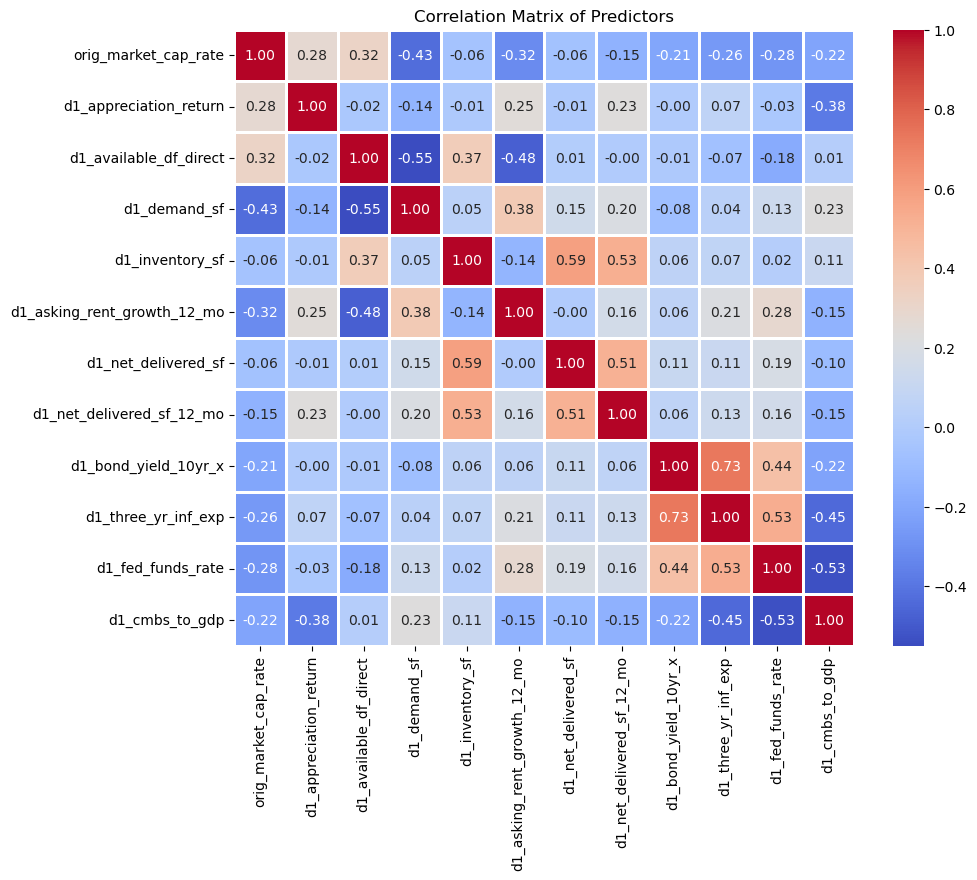

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation matrix
corr_matrix = filtered_df.corr()

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=1)
plt.title("Correlation Matrix of Predictors")
plt.show()


In [ ]:
# -----------------------------
# Standardize the filtered dataset.
#scaler = StandardScaler()
#filtered_df_scaled = pd.DataFrame(
    #scaler.fit_transform(filtered_df),
    #index=filtered_df.index,
    #columns=filtered_df.columns
)

In [87]:
#PCA to reduce 
# Step 1. Prepare Data for Dynamic PCA
# -----------------------------
# Assume 'filtered_df' is your DataFrame containing the target and predictors,
# and it is already time-indexed.
# 'target_transformation' is the name of your target variable.

target_var = target_transformation  # e.g., "orig_market_cap_rate"
predictors_df = filtered_df.drop(columns=[target_var])

# Standardize the predictors.
scaler = StandardScaler()
predictors_scaled = scaler.fit_transform(predictors_df)


In [ ]:
## Step 2 - determine optimal number of components

# Run PCA with all components to extract eigenvalues.
pca_all = PCA(n_components=predictors_scaled.shape[1])
pca_all.fit(predictors_scaled)
eigenvalues = pca_all.explained_variance_
print("Eigenvalues from PCA:", eigenvalues)

# Kaiser criterion: keep components with eigenvalues greater than 1.
n_components_kaiser = np.sum(eigenvalues > 1)
# Ensure at least one component is selected.
n_components_kaiser = max(n_components_kaiser, 1)
print("Number of components selected by Kaiser criterion:", n_components_kaiser)


Eigenvalues from PCA: [2.84147653 2.13958134 1.92353595 1.38083324 0.77660716 0.54648351
 0.4521342  0.38759216 0.32278441 0.23531052 0.16032765]


In [90]:
## Step 3 - Run the PCA with optimal number of components

# Now, run PCA with the number of components determined by the Kaiser criterion.
pca = PCA(n_components=n_components_kaiser)
pca_scores = pca.fit_transform(predictors_scaled)

In [91]:
## Step 4 - Interpret the PCA results

# Create a loading matrix for interpretation.
# Rows: original predictors, Columns: principal components.
loadings = pd.DataFrame(
    pca.components_.T,
    index=predictors_df.columns,
    columns=[f'PC{i+1}' for i in range(n_components_kaiser)]
)
print("\nPCA Loadings Matrix (for interpretation):")
print(loadings)


PCA Loadings Matrix (for interpretation):
                                  PC1       PC2       PC3       PC4
d1_appreciation_return       0.151955 -0.014579 -0.075881  0.721816
d1_available_df_direct      -0.157783  0.453668 -0.370662  0.019739
d1_demand_sf                 0.132054 -0.193322  0.568187 -0.197681
d1_inventory_sf              0.124657  0.575474  0.192091 -0.064052
d1_asking_rent_growth_12_mo  0.274218 -0.328573  0.288414  0.217134
d1_net_delivered_sf          0.247997  0.421518  0.272909 -0.042745
d1_net_delivered_sf_12_mo    0.284849  0.352939  0.305140  0.233182
d1_bond_yield_10yr_x         0.377247  0.000871 -0.283602 -0.360715
d1_three_yr_inf_exp          0.466013 -0.047648 -0.240556 -0.233595
d1_fed_funds_rate            0.456053 -0.099899 -0.101226 -0.156063
d1_cmbs_to_gdp              -0.365693  0.054541  0.312729 -0.350751


In [92]:
## Step 5 - Create a Dataframe with the PCA and target variable

# Create a DataFrame of PCA scores with the same time index as filtered_df.
pca_scores_df = pd.DataFrame(
    pca_scores,
    index=filtered_df.index,
    columns=[f'PC{i+1}' for i in range(n_components_kaiser)]
)

# Merge the target variable with the PCA factors.
final_data_for_VAR = pd.concat([filtered_df[[target_var]], pca_scores_df], axis=1)
print("\nCombined Data for VAR (first few rows):")
print(final_data_for_VAR.head())


Combined Data for VAR (first few rows):
    orig_market_cap_rate       PC1       PC2       PC3       PC4
30              7.442327 -0.918925 -0.559387  1.544642 -1.187550
31              7.610319 -0.046372  3.698440  2.595524 -0.429980
32              7.815240 -3.552555  0.243265 -0.363648 -1.402957
33              8.111285 -0.674960  2.685740 -0.509623 -2.199834
34              8.426096 -1.209948  0.811849 -2.592377 -1.468134


In [93]:
var_model = VAR(final_data_for_VAR)

# Set a maximum lag order (e.g., 8), but note that the available degrees of freedom will limit the optimal lag.
maxlags = 4
try:
    order_results = var_model.select_order(maxlags=maxlags)
    optimal_lag = order_results.aic  # Optimal lag order based on AIC.
    print("\nOptimal lag order selected by AIC:", optimal_lag)
except Exception as e:
    print(f"\nError in lag selection: {e}. Defaulting to lag=1")
    optimal_lag = 1

# Fit the VAR model using the selected lag order.
var_results = var_model.fit(optimal_lag)
print("\nVAR Model Summary:")
print(var_results.summary())


Optimal lag order selected by AIC: 4

VAR Model Summary:
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Fri, 21, Feb, 2025
Time:                     15:26:22
--------------------------------------------------------------------
No. of Equations:         5.00000    BIC:                  -0.363630
Nobs:                     63.0000    HQIC:                  -2.53068
Log likelihood:          -217.997    FPE:                  0.0223011
AIC:                     -3.93552    Det(Omega_mle):      0.00529216
--------------------------------------------------------------------
Results for equation orig_market_cap_rate
                             coefficient       std. error           t-stat            prob
------------------------------------------------------------------------------------------
const                          -0.070609         0.255242           -0.277           0.782
L1.orig_market_cap_rate         1.5113

/Users/elyas/Applications/anaconda3/envs/gatech_02/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


In [110]:
#export results for the equestion orig_market_cap_rate include coefficients and p-values and standard errors and t-statistics
# Extract coefficients, p-values, standard errors, and t-statistics for the target variable.
coefficients = var_results.params[target_var]
p_values = var_results.pvalues[target_var]
standard_errors = var_results.bse[target_var]
t_statistics = var_results.tvalues[target_var]
# Combine into a DataFrame for better readability.
results_df = pd.DataFrame({
    'Coefficient': coefficients,
    'P-Value': p_values,
    'Standard Error': standard_errors,
    'T-Statistic': t_statistics
})
results_df = results_df.reset_index()
results_df.columns = ['Variable', 'Coefficient', 'P-Value', 'Standard Error', 'T-Statistic']
# Save the results to a excel file
results_df.to_excel('/Users/elyas/vscode/market_analysis_03_office/data/var_results.xlsx', index=False)


In [95]:
# Extract the p-values and coefficients for the 'orig_market_cap_rate' equation
pvalues_eq = var_results.pvalues['orig_market_cap_rate']
params_eq = var_results.params['orig_market_cap_rate']

# Filter to include only those coefficients with p-values less than 0.10
significant_mask = pvalues_eq < 0.10
significant_params = params_eq[significant_mask]
significant_pvalues = pvalues_eq[significant_mask]

# Format the p-values to three decimal places (e.g., "0.000")
formatted_pvalues = significant_pvalues.apply(lambda x: f"{x:.3f}")

# Combine into a single DataFrame for presentation
significant_results = pd.DataFrame({
    'Coefficient': significant_params,
    'p-value': formatted_pvalues
})

print("Significant coefficients for the 'orig_market_cap_rate' equation (p < 0.10):")
print(significant_results)


Significant coefficients for the 'orig_market_cap_rate' equation (p < 0.10):
                         Coefficient p-value
L1.orig_market_cap_rate     1.511394   0.000
L1.PC4                     -0.053552   0.000
L2.orig_market_cap_rate    -0.533207   0.036
L2.PC1                      0.011813   0.057
L3.PC2                      0.021950   0.007
L4.PC1                      0.016383   0.007


In [97]:

# Assume:
# - predictors_df is your original (unscaled) data (a DataFrame with the predictors).
# - loadings is your PCA loadings matrix (a DataFrame) with index matching predictors_df.columns.

# First, compute the standard deviation of each predictor from the original data.
predictors_std = predictors_df.std()

# Now, unscale the PCA loadings by dividing each row (each variable) by its standard deviation.
# This gives you the sensitivity of each principal component to a one-unit change in the original variable.
unscaled_loadings = loadings.divide(predictors_std, axis=0)

print("Unscaled PCA Loadings (interpreted in original units):")
print(unscaled_loadings)

Unscaled PCA Loadings (interpreted in original units):
                                      PC1           PC2           PC3  \
d1_appreciation_return       6.301675e-02 -6.045999e-03 -3.146855e-02   
d1_available_df_direct      -1.280205e-07  3.680933e-07 -3.007449e-07   
d1_demand_sf                 1.324203e-07 -1.938584e-07  5.697634e-07   
d1_inventory_sf              1.912100e-07  8.827112e-07  2.946464e-07   
d1_asking_rent_growth_12_mo  4.033104e-01 -4.832550e-01  4.241894e-01   
d1_net_delivered_sf          2.951058e-07  5.015894e-07  3.247502e-07   
d1_net_delivered_sf_12_mo    3.252838e-07  4.030396e-07  3.484558e-07   
d1_bond_yield_10yr_x         1.028894e+00  2.376291e-03 -7.734889e-01   
d1_three_yr_inf_exp          1.848381e+00 -1.889913e-01 -9.541351e-01   
d1_fed_funds_rate            8.243944e-01 -1.805842e-01 -1.829842e-01   
d1_cmbs_to_gdp              -1.242487e+00  1.853085e-01  1.062533e+00   

                                      PC4  
d1_appreciation_return  

In [98]:
predictors_std = predictors_df.std()

In [102]:
predictors_std.head(15)

d1_appreciation_return         2.411343e+00
d1_available_df_direct         1.232481e+06
d1_demand_sf                   9.972334e+05
d1_inventory_sf                6.519386e+05
d1_asking_rent_growth_12_mo    6.799172e-01
d1_net_delivered_sf            8.403651e+05
d1_net_delivered_sf_12_mo      8.756936e+05
d1_bond_yield_10yr_x           3.666531e-01
d1_three_yr_inf_exp            2.521198e-01
d1_fed_funds_rate              5.531979e-01
d1_cmbs_to_gdp                 2.943236e-01
dtype: float64

In [ ]:
0.456053/.531979

0.8572763210577862

In [ ]:
#export 
unscaled_loadings.to_excel('/Users/elyas/vscode/market_analysis_03_office/data/output/unscaled_loadings.xlsx')
predictors_std.to_excel('/Users/elyas/vscode/market_analysis_03_office/data/output/predictors_std.xlsx')
final_data_for_VAR.to_excel('/Users/elyas/vscode/market_analysis_03_office/data/output/final_data_for_VAR.xlsx')
loadings.to_excel('/Users/elyas/vscode/market_analysis_03_office/data/output/loadings.xlsx')
significant_results.to_excel('/Users/elyas/vscode/market_analysis_03_office/data/output/significant_results.xlsx')
